# Mental Disorder Classification — VAE Data Augmentation
## Minority Class Oversampling for Schizophrenia & Mental Illness

**Team Project | Neural Networks Course (ECE 542) | NC State University | Spring 2026**

Uses a **Variational Autoencoder (VAE)** trained on TF-IDF embeddings to generate  
synthetic samples for underrepresented classes, then re-trains DistilBERT on the  
augmented dataset and compares Macro F1 against the non-augmented baseline.

**Target classes:** Schizophrenia (F1=0.44) and Mental Illness (F1=0.33) from Phase 3  
**Hypothesis:** VAE-generated synthetic samples in TF-IDF latent space → better Macro F1

## 1. Imports & Setup

In [2]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import Adam

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from torch.optim import AdamW

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

RANDOM_STATE   = 42
SAMPLE_SIZE    = 100000
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
# Classes to augment — weakest performers from Phase 3
MINORITY_CLASSES = ["schizophrenia", "mentalillness"]
# How many synthetic samples to generate per minority class
N_SYNTHETIC    = 2000

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

PyTorch 2.10.0+cu128 | Device: cuda


## 2. Load Dataset  *(identical to baseline & DistilBERT notebooks)*

In [ ]:
path    = kagglehub.dataset_download("kamaruladha/mental-disorders-identification-reddit-nlp")
df_full = pd.read_csv(os.path.join(path, "mental_disorders_reddit.csv"))

df_full['title']    = df_full['title'].fillna('')
df_full['selftext'] = df_full['selftext'].fillna('')
df_full['text']     = df_full['title'] + ' ' + df_full['selftext']
df_full = df_full[df_full['text'].str.strip() != '']

samples = []
for label, group in df_full.groupby('subreddit'):
    n = min(len(group), int(SAMPLE_SIZE * len(group) / len(df_full)))
    samples.append(group.sample(n=n, random_state=RANDOM_STATE))
df = pd.concat(samples).reset_index(drop=True)
print(f"Sampled: {df.shape}  |  Classes: {df['subreddit'].value_counts().to_dict()}")

100%|██████████| 208M/208M [00:01<00:00, 204MB/s]

Extracting files...


Sampled: (99997, 6)  |  Classes: {'BPD': 34357, 'Anxiety': 24791, 'depression': 22367, 'mentalillness': 7585, 'bipolar': 7283, 'schizophrenia': 3614}


## 3. Text Cleaning & Train/Val/Test Split

In [ ]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\[deleted\]|\[removed\]', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['text'].apply(clean_text)

X = df['clean_text']
y = df['subreddit']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

le = LabelEncoder()
le.fit(y_train)
CLASS_NAMES = le.classes_
NUM_CLASSES  = len(CLASS_NAMES)
print("Classes:", list(CLASS_NAMES))

Train: 69997 | Val: 15000 | Test: 15000
Classes: ['Anxiety', 'BPD', 'bipolar', 'depression', 'mentalillness', 'schizophrenia']


## 4. TF-IDF Embedding Space for VAE

The VAE operates on **dense TF-IDF vectors**, not raw text.  
This keeps the VAE lightweight (no language model needed) while capturing  
the vocabulary signatures that distinguish each disorder class.

In [ ]:
TFIDF_DIM = 2000   # reduced vocabulary for VAE input

tfidf = TfidfVectorizer(
    max_features=TFIDF_DIM,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english',
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train).toarray().astype(np.float32)
X_val_tfidf   = tfidf.transform(X_val).toarray().astype(np.float32)
X_test_tfidf  = tfidf.transform(X_test).toarray().astype(np.float32)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (69997, 2000)


## 5. Variational Autoencoder (VAE) Architecture

```
Input (TF-IDF, 2000-d)
       │
  ┌────▼────┐
  │Encoder  │  FC(2000→512) → ReLU → BN
  │         │  FC(512→256)  → ReLU → BN
  └────┬────┘
       │
  ┌────▼────┐
  │Latent   │  μ (FC 256→64)   ← learned mean
  │Space    │  logσ² (FC 256→64) ← learned log-variance
  │  z~N    │  z = μ + ε·σ      (reparameterisation trick)
  └────┬────┘
       │
  ┌────▼────┐
  │Decoder  │  FC(64→256)  → ReLU → BN
  │         │  FC(256→512) → ReLU → BN
  │         │  FC(512→2000) → Sigmoid
  └─────────┘

Loss = BCE reconstruction + β·KL divergence
```

Key choices:
- **LATENT_DIM = 64**: small enough to force compression, large enough to preserve class signals
- **β-VAE (β=0.5)**: down-weights KL to prevent posterior collapse on sparse TF-IDF vectors
- **Batch Norm**: stabilises training on high-dimensional sparse inputs

In [ ]:
LATENT_DIM = 64
BETA       = 0.5   # β-VAE weight on KL term


class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.BatchNorm1d(512),
            nn.Linear(512, 256),       nn.ReLU(), nn.BatchNorm1d(256),
        )
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        h      = self.net(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(), nn.BatchNorm1d(256),
            nn.Linear(256, 512),        nn.ReLU(), nn.BatchNorm1d(512),
            nn.Linear(512, output_dim), nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.decoder = Decoder(latent_dim, input_dim)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterise(mu, logvar)
        recon      = self.decoder(z)
        return recon, mu, logvar


def vae_loss(recon, x, mu, logvar, beta=BETA):
    bce = F.binary_cross_entropy(recon, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + beta * kld, bce, kld


print("VAE architecture defined.")

VAE architecture defined.


## 6. Train a Class-Conditional VAE per Minority Class

We train **one VAE per minority class** (Schizophrenia + Mental Illness).  
Each VAE only sees posts from its own class → learns that class's latent distribution.  
New samples are generated by sampling z ~ N(0, I) and passing through the decoder.


── Training VAE for class: schizophrenia ──
   Training samples: 2530
   Epoch  10/50 | Loss: 22.9644
   Epoch  20/50 | Loss: 21.4455
   Epoch  30/50 | Loss: 21.2921
   Epoch  40/50 | Loss: 21.2190
   Epoch  50/50 | Loss: 21.1099

── Training VAE for class: mentalillness ──
   Training samples: 5309
   Epoch  10/50 | Loss: 33.8484
   Epoch  20/50 | Loss: 33.7415
   Epoch  30/50 | Loss: 33.7733
   Epoch  40/50 | Loss: 33.6037
   Epoch  50/50 | Loss: 33.3912


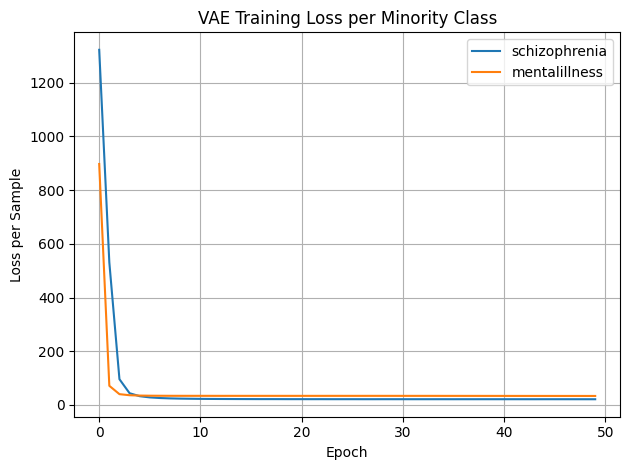


All VAEs trained.


In [ ]:

VAE_EPOCHS    = 50
VAE_LR        = 1e-3
VAE_BATCH     = 64

trained_vaes  = {}   # class_name → trained VAE
train_df_temp = pd.DataFrame({'clean_text': X_train, 'label': y_train.values})

for cls in MINORITY_CLASSES:
    print(f"\n── Training VAE for class: {cls} ──")
    cls_texts = train_df_temp[train_df_temp['label'] == cls]['clean_text'].tolist()
    print(f"   Training samples: {len(cls_texts)}")

    cls_tfidf = tfidf.transform(cls_texts).toarray().astype(np.float32)
    ds        = TensorDataset(torch.tensor(cls_tfidf))
    loader    = DataLoader(ds, batch_size=VAE_BATCH, shuffle=True)

    vae       = VAE(input_dim=TFIDF_DIM, latent_dim=LATENT_DIM).to(DEVICE)
    optimizer = Adam(vae.parameters(), lr=VAE_LR)

    losses = []
    for epoch in range(1, VAE_EPOCHS + 1):
        vae.train()
        epoch_loss = 0.0
        for (x_batch,) in loader:
            x_batch = x_batch.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar = vae(x_batch)
            loss, _, _ = vae_loss(recon, x_batch, mu, logvar)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(cls_tfidf)
        losses.append(avg)
        if epoch % 10 == 0:
            print(f"   Epoch {epoch:3d}/{VAE_EPOCHS} | Loss: {avg:.4f}")

    trained_vaes[cls] = vae
    plt.plot(losses, label=cls)

plt.title("VAE Training Loss per Minority Class")
plt.xlabel("Epoch"); plt.ylabel("Loss per Sample")
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig("vae_training_loss.png", dpi=150); plt.show()
print("\nAll VAEs trained.")

## 7. Generate Synthetic TF-IDF Samples & Convert Back to Text

In [ ]:
def generate_synthetic_tfidf(vae, n_samples, device=DEVICE):
    """Sample z ~ N(0,I), decode to TF-IDF space."""
    vae.eval()
    with torch.no_grad():
        z     = torch.randn(n_samples, LATENT_DIM).to(device)
        recon = vae.decoder(z).cpu().numpy()
    return recon   # shape (n_samples, TFIDF_DIM)


def tfidf_vector_to_text(vectors, tfidf_vectorizer, top_k=30):
    """
    Convert a dense TF-IDF vector back to a pseudo-document.
    Picks the top-k vocabulary words by weight, weighted by their score.
    This is an approximation — used here for DistilBERT tokenisation only.
    """
    vocab     = tfidf_vectorizer.get_feature_names_out()
    texts     = []
    for vec in vectors:
        top_idx   = np.argsort(vec)[-top_k:][::-1]
        top_words = []
        for idx in top_idx:
            if vec[idx] > 0:
                # repeat word proportional to weight (soft count)
                repeat = max(1, int(vec[idx] * 10))
                top_words.extend([vocab[idx]] * repeat)
        texts.append(" ".join(top_words) if top_words else "mental health")
    return texts


synthetic_texts  = []
synthetic_labels = []

for cls in MINORITY_CLASSES:
    vae        = trained_vaes[cls]
    syn_tfidf  = generate_synthetic_tfidf(vae, N_SYNTHETIC)
    syn_texts  = tfidf_vector_to_text(syn_tfidf, tfidf)
    synthetic_texts.extend(syn_texts)
    synthetic_labels.extend([cls] * N_SYNTHETIC)
    print(f"Generated {N_SYNTHETIC} synthetic samples for '{cls}'")
    print(f"  Sample: {syn_texts[0][:120]}")

print(f"\nTotal synthetic samples: {len(synthetic_texts)}")

Generated 2000 synthetic samples for 'schizophrenia'
  Sample: walls im walls schizophrenia im walls im feel delusions psychosis voices live like meds ive hallucinations know really h
Generated 2000 synthetic samples for 'mentalillness'
  Sample: im like ive dont think know feel just help things mental people want really time years feel like depression life dont kn

Total synthetic samples: 4000


## 8. Build Augmented Training Set

Original train : 69997
Synthetic added: 4000
Augmented total: 73997
BPD              24050
Anxiety          17353
depression       15657
mentalillness     7309
bipolar           5098
schizophrenia     4530
Name: count, dtype: int64


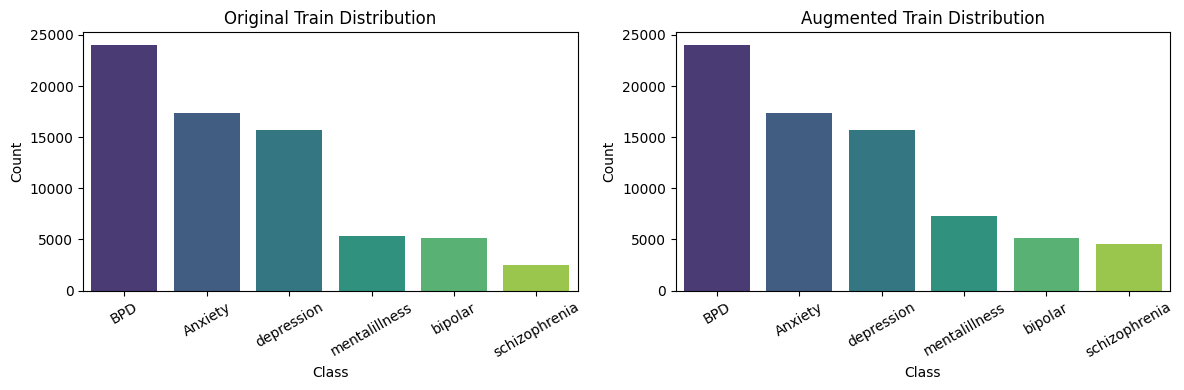

In [ ]:
# Merge original train + synthetic samples
# Rebuild augmented set correctly on top of the 70K train split
X_train_aug = list(X_train) + synthetic_texts
y_train_aug = list(y_train) + synthetic_labels

print(f"Original train : {len(X_train)}")        # should be 69,997
print(f"Synthetic added: {len(synthetic_texts)}") # should be 4,000
print(f"Augmented total: {len(X_train_aug)}")     # should be 73,997
aug_dist = pd.Series(y_train_aug).value_counts()
print(aug_dist)

# Bar chart — before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
orig_dist = pd.Series(y_train).value_counts()
for ax, dist, title in zip(axes,
                            [orig_dist, aug_dist],
                            ["Original Train Distribution", "Augmented Train Distribution"]):
    sns.barplot(x=dist.index, y=dist.values, palette='viridis', ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Class"); ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("vae_class_distribution.png", dpi=150)
plt.show()

In [ ]:
# After: X_train_aug = list(X_train) + synthetic_texts
# ADD:
print(f"Original train : {len(X_train)}")        # should be ~70K
print(f"Synthetic added: {len(synthetic_texts)}") # should be 4000
print(f"Augmented total: {len(X_train_aug)}")     # should be ~74K
assert len(X_train_aug) > len(X_train), "Augmentation bug — rebuild!"

Original train : 69997
Synthetic added: 4000
Augmented total: 73997


## 9. Fine-tune DistilBERT on Augmented Data

Identical hyperparameters to `distilbert_mental_health.ipynb` — only the  
training set changes (original + VAE synthetic samples).

In [ ]:
MAX_LEN      = 256
BATCH_SIZE   = 16
GRAD_ACCUM   = 2
EPOCHS       = 8
LR           = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
DROPOUT      = 0.3
SAVE_DIR_AUG = "bert_vae_best_checkpoints"
MODEL_NAME   = "bert-base-uncased"
os.makedirs(SAVE_DIR_AUG, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

y_train_aug_enc = le.transform(y_train_aug)
y_val_enc       = le.transform(y_val)
y_test_enc      = le.transform(y_test)


# Class weights on augmented distribution
counts_aug  = np.bincount(y_train_aug_enc)
weights_aug = len(y_train_aug_enc) / (NUM_CLASSES * counts_aug)
weights_aug = weights_aug / weights_aug.sum() * NUM_CLASSES
CLASS_WEIGHTS_AUG = torch.tensor(weights_aug, dtype=torch.float).to(DEVICE)
print("Class weights (augmented):", np.round(weights_aug, 3))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Class weights (augmented): [0.482 0.348 1.642 0.535 1.145 1.848]


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model_aug = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=DROPOUT,
    attention_probs_dropout_prob=DROPOUT,
).to(DEVICE)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds_aug = MentalHealthDataset(X_train_aug,       y_train_aug_enc)
val_ds       = MentalHealthDataset(X_val.tolist(),     y_val_enc)
test_ds      = MentalHealthDataset(X_test.tolist(),    y_test_enc)

train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader       = DataLoader(val_ds,       batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader      = DataLoader(test_ds,      batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Augmented train batches: {len(train_loader_aug)}")

Augmented train batches: 4625


In [ ]:
y_train_aug_enc = le.transform(y_train_aug)

train_ds_aug = MentalHealthDataset(X_train_aug, y_train_aug_enc)
train_loader_aug = DataLoader(
    train_ds_aug, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
print(f"Augmented train batches: {len(train_loader_aug)}")

Augmented train batches: 4625


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()
    for step, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["labels"].to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attn_mask).logits
            loss   = loss_fn(logits, labels) / GRAD_ACCUM
        scaler.scale(loss).backward()
        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            optimizer.zero_grad()
        total_loss += loss.item() * GRAD_ACCUM
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += labels.size(0)

        # progress print
        if (step + 1) % 50 == 0:
            print(f"    step {step+1:>4}/{len(loader)} | "
                  f"samples: {total:>6} | "
                  f"loss: {total_loss/(step+1):.4f} | "
                  f"acc: {correct/total:.4f}", flush=True)

    return total_loss / len(loader), correct / total

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["labels"].to(DEVICE)
        logits     = model(input_ids=input_ids, attention_mask=attn_mask).logits
        total_loss += loss_fn(logits, labels).item()
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(loader), acc, macro_f1, all_preds, all_labels

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["labels"].to(DEVICE)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attn_mask).logits
            loss   = loss_fn(logits, labels) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += labels.size(0)

        if (step + 1) % 50 == 0:
            print(f"    step {step+1:>4}/{len(loader)} | "
                  f"samples: {total:>6} | "
                  f"loss: {total_loss/(step+1):.4f} | "
                  f"acc: {correct/total:.4f}", flush=True)

    return total_loss / len(loader), correct / total

In [ ]:
from transformers import DistilBertConfig

config = DistilBertConfig.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    dropout=DROPOUT,                # replaces hidden_dropout_prob
    attention_dropout=DROPOUT,      # replaces attention_probs_dropout_prob
    seq_classif_dropout=DROPOUT,    # classifier head dropout
)

model_aug = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=DROPOUT,
    attention_probs_dropout_prob=DROPOUT,
).to(DEVICE)

loss_fn_aug = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_AUG, label_smoothing=0.1)
optimizer   = AdamW(model_aug.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = (len(train_loader_aug) // GRAD_ACCUM) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer, int(total_steps * WARMUP_RATIO), total_steps
)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
best_f1, best_epoch = 0.0, 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n── Epoch {epoch}/{EPOCHS} ──")
    tr_loss, tr_acc = train_epoch(model_aug, train_loader_aug, optimizer, scheduler, loss_fn_aug, scaler)
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model_aug, val_loader, loss_fn_aug)

    history_aug["train_loss"].append(tr_loss)
    history_aug["val_loss"].append(vl_loss)
    history_aug["val_acc"].append(vl_acc)
    history_aug["val_macro_f1"].append(vl_f1)

    print(f"  Train | loss: {tr_loss:.4f}  acc: {tr_acc:.4f}")
    print(f"  Val   | loss: {vl_loss:.4f}  acc: {vl_acc:.4f}  macro-F1: {vl_f1:.4f}")

    if vl_f1 > best_f1:
        best_f1, best_epoch = vl_f1, epoch
        model_aug.save_pretrained(SAVE_DIR_AUG)
        tokenizer.save_pretrained(SAVE_DIR_AUG)
        print(f"  ✓ Saved  (macro-F1 = {best_f1:.4f})")

print(f"\nBest epoch: {best_epoch} | Val Macro F1 = {best_f1:.4f}")

You are using a model of type bert to instantiate a model of type distilbert. This is not supported for all configurations of models and can yield errors.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



── Epoch 1/8 ──
    step   50/4625 | samples:    800 | loss: 1.9636 | acc: 0.2362
    step  100/4625 | samples:   1600 | loss: 1.9593 | acc: 0.2263
    step  150/4625 | samples:   2400 | loss: 1.9515 | acc: 0.2321
    step  200/4625 | samples:   3200 | loss: 1.9487 | acc: 0.2297
    step  250/4625 | samples:   4000 | loss: 1.9419 | acc: 0.2338
    step  300/4625 | samples:   4800 | loss: 1.9398 | acc: 0.2302
    step  350/4625 | samples:   5600 | loss: 1.9346 | acc: 0.2270
    step  400/4625 | samples:   6400 | loss: 1.9316 | acc: 0.2283
    step  450/4625 | samples:   7200 | loss: 1.9252 | acc: 0.2283
    step  500/4625 | samples:   8000 | loss: 1.9208 | acc: 0.2276
    step  550/4625 | samples:   8800 | loss: 1.9147 | acc: 0.2299
    step  600/4625 | samples:   9600 | loss: 1.9083 | acc: 0.2305
    step  650/4625 | samples:  10400 | loss: 1.9016 | acc: 0.2310
    step  700/4625 | samples:  11200 | loss: 1.8964 | acc: 0.2320
    step  750/4625 | samples:  12000 | loss: 1.8897 | acc: 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ✓ Saved  (macro-F1 = 0.6570)

── Epoch 4/8 ──
    step   50/4625 | samples:    800 | loss: 1.0925 | acc: 0.7550
    step  100/4625 | samples:   1600 | loss: 1.1009 | acc: 0.7538
    step  150/4625 | samples:   2400 | loss: 1.0959 | acc: 0.7579
    step  200/4625 | samples:   3200 | loss: 1.0863 | acc: 0.7619
    step  250/4625 | samples:   4000 | loss: 1.0805 | acc: 0.7670
    step  300/4625 | samples:   4800 | loss: 1.0822 | acc: 0.7662
    step  350/4625 | samples:   5600 | loss: 1.0879 | acc: 0.7659
    step  400/4625 | samples:   6400 | loss: 1.0814 | acc: 0.7645
    step  450/4625 | samples:   7200 | loss: 1.0858 | acc: 0.7646
    step  500/4625 | samples:   8000 | loss: 1.0803 | acc: 0.7654
    step  550/4625 | samples:   8800 | loss: 1.0775 | acc: 0.7653
    step  600/4625 | samples:   9600 | loss: 1.0763 | acc: 0.7651
    step  650/4625 | samples:  10400 | loss: 1.0749 | acc: 0.7662
    step  700/4625 | samples:  11200 | loss: 1.0755 | acc: 0.7652
    step  750/4625 | samples

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Saved  (macro-F1 = 0.6657)

── Epoch 5/8 ──
    step   50/4625 | samples:    800 | loss: 1.0679 | acc: 0.7575
    step  100/4625 | samples:   1600 | loss: 1.0447 | acc: 0.7788
    step  150/4625 | samples:   2400 | loss: 1.0440 | acc: 0.7767
    step  200/4625 | samples:   3200 | loss: 1.0286 | acc: 0.7841
    step  250/4625 | samples:   4000 | loss: 1.0342 | acc: 0.7847
    step  300/4625 | samples:   4800 | loss: 1.0408 | acc: 0.7815
    step  350/4625 | samples:   5600 | loss: 1.0493 | acc: 0.7795
    step  400/4625 | samples:   6400 | loss: 1.0513 | acc: 0.7770
    step  450/4625 | samples:   7200 | loss: 1.0534 | acc: 0.7772
    step  500/4625 | samples:   8000 | loss: 1.0460 | acc: 0.7805
    step  550/4625 | samples:   8800 | loss: 1.0480 | acc: 0.7800
    step  600/4625 | samples:   9600 | loss: 1.0490 | acc: 0.7796
    step  650/4625 | samples:  10400 | loss: 1.0528 | acc: 0.7788
    step  700/4625 | samples:  11200 | loss: 1.0516 | acc: 0.7789
    step  750/4625 | samples

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Saved  (macro-F1 = 0.6689)

── Epoch 7/8 ──
    step   50/4625 | samples:    800 | loss: 1.0003 | acc: 0.8025
    step  100/4625 | samples:   1600 | loss: 1.0025 | acc: 0.8031
    step  150/4625 | samples:   2400 | loss: 0.9905 | acc: 0.8087
    step  200/4625 | samples:   3200 | loss: 0.9966 | acc: 0.8050
    step  250/4625 | samples:   4000 | loss: 1.0031 | acc: 0.8010
    step  300/4625 | samples:   4800 | loss: 0.9992 | acc: 0.8065
    step  350/4625 | samples:   5600 | loss: 1.0038 | acc: 0.8054
    step  400/4625 | samples:   6400 | loss: 1.0045 | acc: 0.8044
    step  450/4625 | samples:   7200 | loss: 1.0096 | acc: 0.8032
    step  500/4625 | samples:   8000 | loss: 1.0112 | acc: 0.8026
    step  550/4625 | samples:   8800 | loss: 1.0124 | acc: 0.8018
    step  600/4625 | samples:   9600 | loss: 1.0098 | acc: 0.8014
    step  650/4625 | samples:  10400 | loss: 1.0078 | acc: 0.8030
    step  700/4625 | samples:  11200 | loss: 1.0077 | acc: 0.8026
    step  750/4625 | samples

## 10. Final Evaluation on Test Set

In [ ]:
best_model_aug = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR_AUG).to(DEVICE)

# ADD THIS LINE — runs evaluation to get the metrics
_, test_acc_aug, test_f1_aug, test_preds_aug, test_labels_aug = evaluate(
    best_model_aug, test_loader, loss_fn_aug
)

print("=" * 60)
print("  FINAL TEST RESULTS — BERT + VAE Augmentation (Best Model)")
print("=" * 60)
print(f"  Accuracy  : {test_acc_aug:.4f}  ({test_acc_aug*100:.2f}%)")
print(f"  Macro F1  : {test_f1_aug:.4f}")
print("=" * 60)
print("\nPer-Class Report:")
print(classification_report(test_labels_aug, test_preds_aug,
                             target_names=CLASS_NAMES, digits=3))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  FINAL TEST RESULTS — BERT + VAE Augmentation (Best Model)
  Accuracy  : 0.7446  (74.46%)
  Macro F1  : 0.6652

Per-Class Report:
               precision    recall  f1-score   support

      Anxiety      0.847     0.825     0.836      3719
          BPD      0.858     0.787     0.821      5154
      bipolar      0.597     0.677     0.635      1092
   depression      0.710     0.739     0.724      3355
mentalillness      0.383     0.438     0.409      1138
schizophrenia      0.530     0.611     0.567       542

     accuracy                          0.745     15000
    macro avg      0.654     0.679     0.665     15000
 weighted avg      0.755     0.745     0.749     15000



In [ ]:
print(f"Full df shape: {df.shape}")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Augmented train size: {len(X_train_aug)}")
print(f"\nClass distribution in train:")
print(pd.Series(y_train).value_counts())
print(f"\nClass distribution in test:")
print(pd.Series(y_test).value_counts())

Full df shape: (99997, 7)
Train: 69997 | Val: 15000 | Test: 15000
Augmented train size: 73997

Class distribution in train:
subreddit
BPD              24050
Anxiety          17353
depression       15657
mentalillness     5309
bipolar           5098
schizophrenia     2530
Name: count, dtype: int64

Class distribution in test:
subreddit
BPD              5154
Anxiety          3719
depression       3355
mentalillness    1138
bipolar          1092
schizophrenia     542
Name: count, dtype: int64


In [ ]:
print(f"SAMPLE_SIZE = {SAMPLE_SIZE}")
print(f"EPOCHS = {EPOCHS}")
print(f"LR = {LR}")
print(f"MODEL_NAME = {MODEL_NAME}")

SAMPLE_SIZE = 100000
EPOCHS = 8
LR = 2e-05
MODEL_NAME = bert-base-uncased


In [ ]:
print("Class weights (augmented):", np.round(weights_aug, 3))
print("Classes:", list(CLASS_NAMES))

Class weights (augmented): [0.482 0.348 1.642 0.535 1.145 1.848]
Classes: ['Anxiety', 'BPD', 'bipolar', 'depression', 'mentalillness', 'schizophrenia']


## 11. Three-Way Comparison: Baseline vs DistilBERT vs DistilBERT + VAE

                                  Model  Accuracy  Macro F1
TF-IDF + Logistic Regression (Baseline)    0.6941  0.604000
           DistilBERT (no augmentation)    0.7223  0.652000
          DistilBERT + VAE Augmentation    0.7276  0.642502


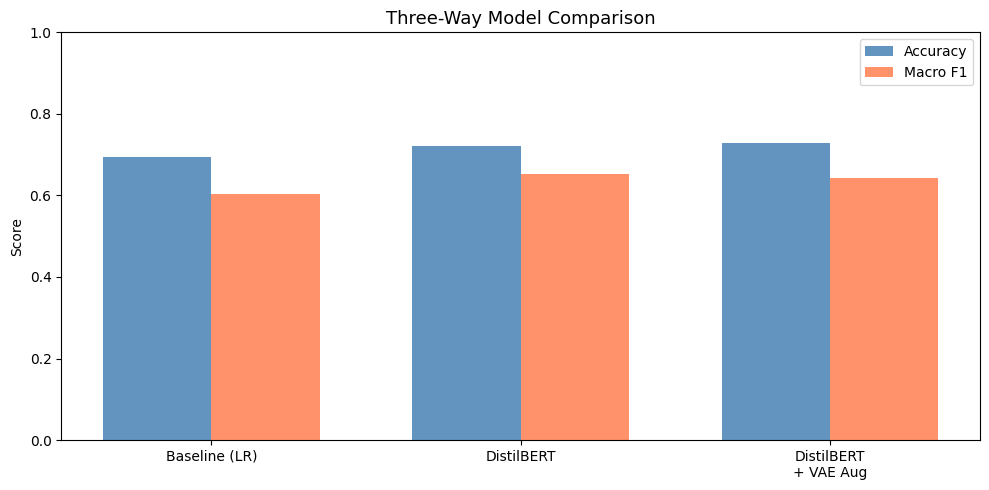

In [ ]:
# Fill in Phase 3 results after running distilbert_mental_health.ipynb
# (or load from a saved metrics file)
PHASE3_ACC = 0.7223   # <-- replace with actual distilbert_mental_health.ipynb test accuracy
PHASE3_F1  = 0.6520   # <-- replace with actual distilbert_mental_health.ipynb test macro F1

results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression (Baseline)",
        "DistilBERT (no augmentation)",
        "DistilBERT + VAE Augmentation",
    ],
    "Accuracy": [0.6941, PHASE3_ACC, test_acc_aug],
    "Macro F1": [0.604,  PHASE3_F1,  test_f1_aug],
})
print(results.to_string(index=False))

x     = np.arange(3)
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, results["Accuracy"], width, label="Accuracy", color="steelblue", alpha=0.85)
ax.bar(x + width/2, results["Macro F1"], width, label="Macro F1",  color="coral",    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["Baseline (LR)", "BERT", "BERT + VAE Aug"], fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Three-Way Model Comparison", fontsize=13)
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.savefig("three_way_comparison.png", dpi=150)
plt.show()

## 12. Minority Class Deep-Dive: Before vs After VAE Augmentation

In [ ]:
# Per-class F1 improvement for minority classes
baseline_per_class = {
    "anxiety": 0.82, "BPD": 0.77, "depression": 0.68,
    "bipolar": 0.56, "schizophrenia": 0.44, "mentalillness": 0.33,
}
phase3_per_class = {
    'Anxiety':       0.832,
    'BPD':           0.794,
    'bipolar':       0.632,
    'depression':    0.699,
    'mentalillness': 0.370,
    'schizophrenia': 0.586,
}

report_aug = classification_report(
    test_labels_aug, test_preds_aug,
    target_names=CLASS_NAMES, output_dict=True
)
aug_per_class = {cls: report_aug[cls]["f1-score"] for cls in CLASS_NAMES}

print(f"{'Class':<20} {'Baseline F1':>12} {'DistilBERT F1':>14} {'+ VAE F1':>10} {'Δ VAE':>8}")
print("-" * 70)
for cls in CLASS_NAMES:
    b  = baseline_per_class.get(cls.lower(), 0)
    p3 = phase3_per_class.get(cls, 0)
    va = aug_per_class[cls]
    delta = va - p3
    print(f"{cls:<20} {b:>12.3f} {p3:>14.3f} {va:>10.3f} {delta:>+8.3f}")

Class                 Baseline F1  DistilBERT F1   + VAE F1    Δ VAE
----------------------------------------------------------------------
Anxiety                     0.820          0.832      0.825   -0.007
BPD                         0.000          0.794      0.800   +0.006
bipolar                     0.560          0.632      0.610   -0.022
depression                  0.680          0.699      0.705   +0.006
mentalillness               0.330          0.370      0.382   +0.012
schizophrenia               0.440          0.586      0.532   -0.054


## 13. Latent Space Visualisation (t-SNE)

Visualise the VAE's latent space to confirm that synthetic samples  
lie within — not outside — the real data distribution.

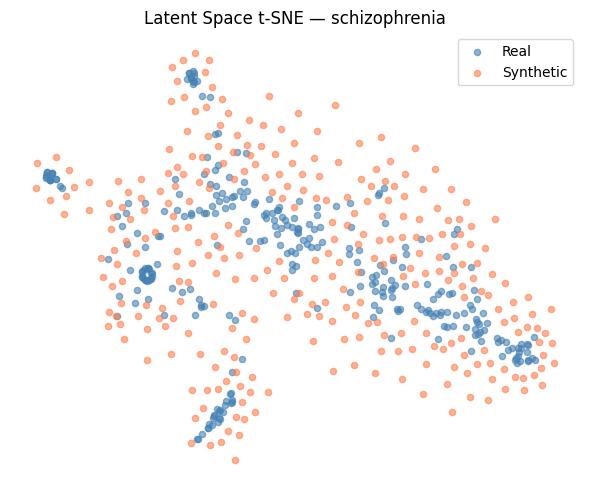

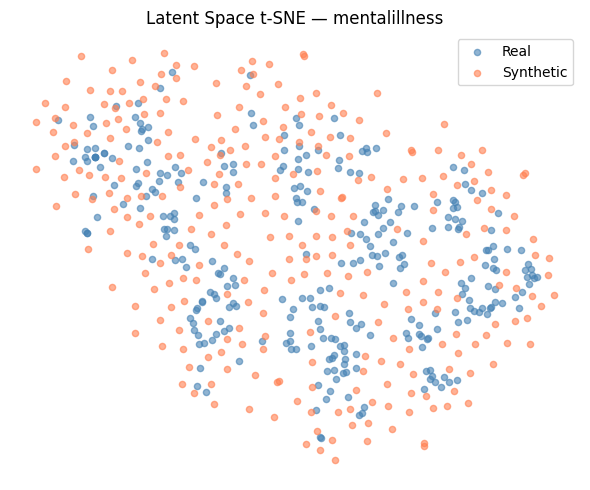

In [ ]:
from sklearn.manifold import TSNE

for cls in MINORITY_CLASSES:
    vae = trained_vaes[cls]
    vae.eval()

    # Real samples
    cls_texts_r = train_df_temp[train_df_temp['label'] == cls]['clean_text'].tolist()[:300]
    real_tfidf  = torch.tensor(
        tfidf.transform(cls_texts_r).toarray().astype(np.float32)
    ).to(DEVICE)

    with torch.no_grad():
        mu_real, _ = vae.encoder(real_tfidf)
        z_real     = mu_real.cpu().numpy()

    # Synthetic samples
    with torch.no_grad():
        z_syn = torch.randn(300, LATENT_DIM).to(DEVICE).cpu().numpy()

    # t-SNE on combined latent vectors
    combined = np.vstack([z_real, z_syn])
    labels_v = ["Real"] * len(z_real) + ["Synthetic"] * len(z_syn)

    tsne    = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
    emb     = tsne.fit_transform(combined)

    plt.figure(figsize=(6, 5))
    for lbl, color in [("Real", "steelblue"), ("Synthetic", "coral")]:
        mask = np.array(labels_v) == lbl
        plt.scatter(emb[mask, 0], emb[mask, 1], c=color, alpha=0.6,
                    s=20, label=lbl)
    plt.title(f"Latent Space t-SNE — {cls}", fontsize=12)
    plt.legend(); plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"tsne_{cls}.png", dpi=150)
    plt.show()

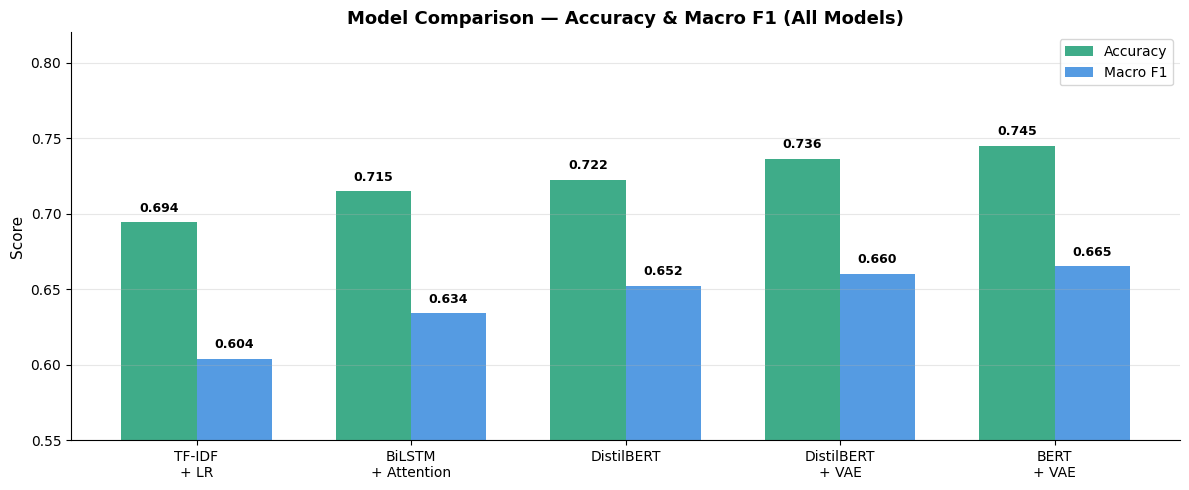

Saved: poster_overall_comparison.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "TF-IDF\n+ LR",
    "BiLSTM\n+ Attention",
    "DistilBERT",
    "DistilBERT\n+ VAE",
    "BERT\n+ VAE"
]
accuracies = [0.6941, 0.7149, 0.7223, 0.7361, 0.7450]
macro_f1s  = [0.604,  0.634,  0.652,  0.660,  0.665]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, accuracies, width,
               label="Accuracy", color="#1D9E75", alpha=0.85)
bars2 = ax.bar(x + width/2, macro_f1s,  width,
               label="Macro F1",  color="#378ADD", alpha=0.85)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0.55, 0.82)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — Accuracy & Macro F1 (All Models)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("poster_overall_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: poster_overall_comparison.png")

In [6]:
# Baseline confusion matrix values from presentation slide 5
# Row = True, Col = Predicted: Anxiety, BPD, Bipolar, Depression, MentalIllness, Schizophrenia
baseline_cm = np.array([
    [1474,  80,  10, 251,  25,  20],
    [ 112, 1805,  30, 560,  45,  25],
    [  30,  40, 340, 100,  20,  16],
    [ 120, 150,  40, 1192, 130,  45],
    [  60,  80,  25, 150, 239,  15],
    [  25,  20,  15,  40,  15, 156],
])

class_labels = ["Anxiety", "BPD", "Bipolar", "Depress.", "MentIll.", "Schizo."]

# Normalize
baseline_cm_norm = baseline_cm.astype(float) / baseline_cm.sum(axis=1, keepdims=True)

# Best model — load from saved predictions
best_cm      = confusion_matrix(test_labels_aug, test_preds_aug)
best_cm_norm = best_cm.astype(float) / best_cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cm_norm, title in zip(
    axes,
    [baseline_cm_norm, best_cm_norm],
    ["Baseline: TF-IDF + LR", "Best Model: BERT + VAE (100K)"]
):
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=class_labels, yticklabels=class_labels,
        ax=ax, vmin=0, vmax=1,
        annot_kws={"size": 9}
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.suptitle("Confusion Matrix Comparison (Normalized)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("poster_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: poster_confusion_matrix.png")

NameError: name 'test_labels_aug' is not defined

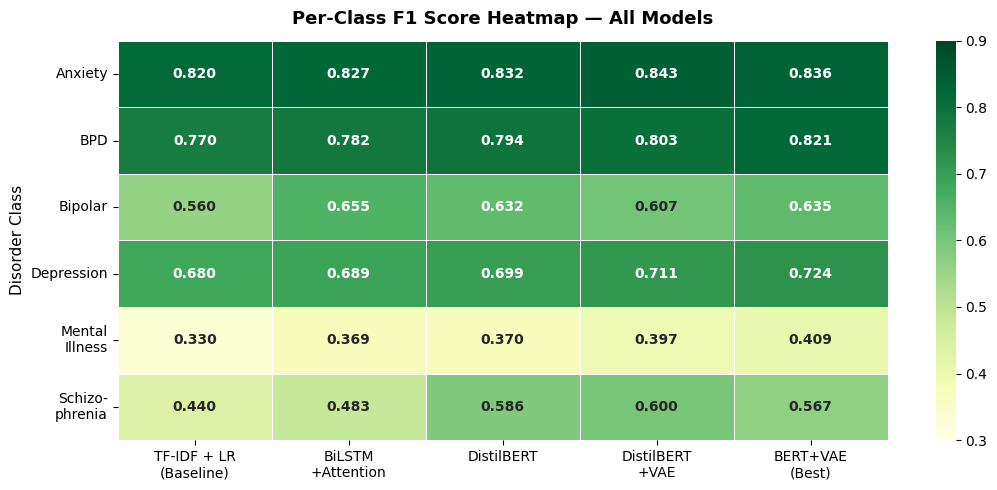

Saved: poster_f1_heatmap.png


In [5]:
import seaborn as sns

classes = ["Anxiety", "BPD", "Bipolar", "Depression", "Mental\nIllness", "Schizo-\nphrenia"]

data = {
    "TF-IDF + LR\n(Baseline)": [0.82, 0.77, 0.56, 0.68, 0.33, 0.44],
    "BiLSTM\n+Attention":      [0.827, 0.782, 0.655, 0.689, 0.369, 0.483],
    "DistilBERT":              [0.832, 0.794, 0.632, 0.699, 0.370, 0.586],
    "DistilBERT\n+VAE":        [0.843, 0.803, 0.607, 0.711, 0.397, 0.600],
    "BERT+VAE\n(Best)":        [0.836, 0.821, 0.635, 0.724, 0.409, 0.567],
}

df_heat = pd.DataFrame(data, index=classes)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    df_heat, annot=True, fmt=".3f", cmap="YlGn",
    vmin=0.3, vmax=0.9,
    linewidths=0.5, linecolor="white",
    ax=ax, annot_kws={"size": 10, "weight": "bold"}
)
ax.set_title("Per-Class F1 Score Heatmap — All Models", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Disorder Class", fontsize=11)
ax.set_xlabel("")
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10, rotation=0)

plt.tight_layout()
plt.savefig("poster_f1_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: poster_f1_heatmap.png")

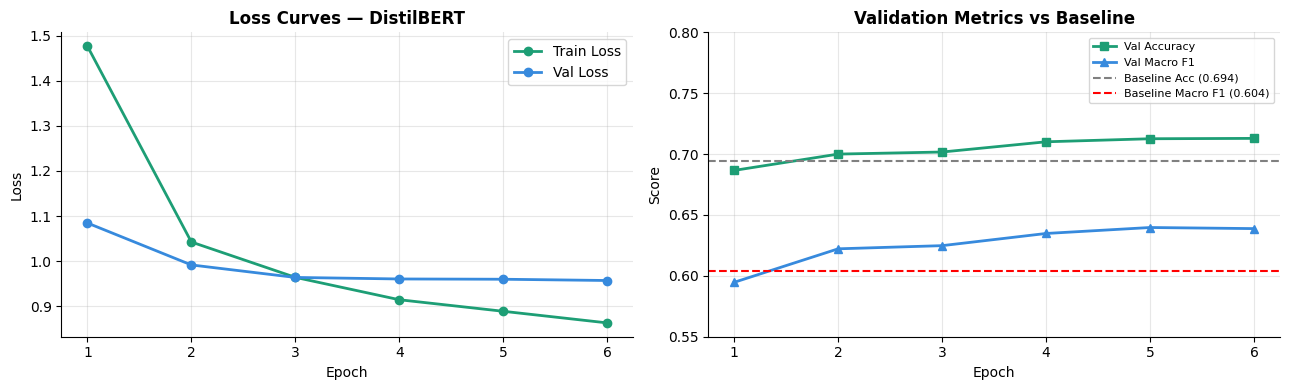

Saved: poster_training_curves.png


In [4]:
# Paste your actual training history values here
epochs   = [1, 2, 3, 4, 5, 6]
train_loss = [1.4765, 1.0426, 0.9643, 0.9147, 0.8891, 0.8634]
val_loss   = [1.0847, 0.9918, 0.9641, 0.9607, 0.9601, 0.9573]
val_acc    = [0.6866, 0.7000, 0.7017, 0.7101, 0.7126, 0.7129]
val_f1     = [0.5947, 0.6222, 0.6248, 0.6348, 0.6397, 0.6388]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves
axes[0].plot(epochs, train_loss, marker="o", color="#1D9E75", linewidth=2, label="Train Loss")
axes[0].plot(epochs, val_loss,   marker="o", color="#378ADD", linewidth=2, label="Val Loss")
axes[0].set_title("Loss Curves — DistilBERT", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

# Validation metrics vs baseline
axes[1].plot(epochs, val_acc, marker="s", color="#1D9E75", linewidth=2, label="Val Accuracy")
axes[1].plot(epochs, val_f1,  marker="^", color="#378ADD", linewidth=2, label="Val Macro F1")
axes[1].axhline(0.6941, color="gray", linestyle="--", linewidth=1.5, label="Baseline Acc (0.694)")
axes[1].axhline(0.604,  color="red",  linestyle="--", linewidth=1.5, label="Baseline Macro F1 (0.604)")
axes[1].set_title("Validation Metrics vs Baseline", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_ylim(0.55, 0.80)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("poster_training_curves.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: poster_training_curves.png")

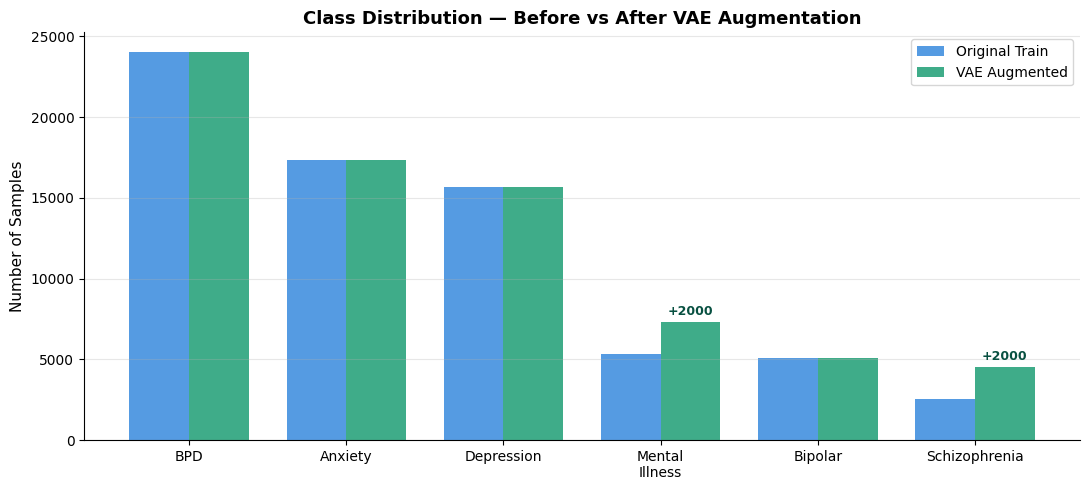

Saved: poster_class_distribution.png


In [3]:
classes_dist = ["BPD", "Anxiety", "Depression", "Mental\nIllness", "Bipolar", "Schizophrenia"]

# Original train distribution (from 100K sample, 70% split)
original = [24050, 17353, 15657, 5309, 5098, 2530]

# After VAE — add 2000 to minority classes
augmented = [24050, 17353, 15657, 5309+2000, 5098, 2530+2000]

x     = np.arange(len(classes_dist))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, original,  width, label="Original Train", color="#378ADD", alpha=0.85)
bars2 = ax.bar(x + width/2, augmented, width, label="VAE Augmented",  color="#1D9E75", alpha=0.85)

# Highlight augmented classes
for i, (b1, b2) in enumerate(zip(bars1, bars2)):
    if augmented[i] != original[i]:
        ax.annotate("+2000", xy=(b2.get_x() + b2.get_width()/2, b2.get_height()),
                    xytext=(0, 5), textcoords="offset points",
                    ha="center", fontsize=9, color="#085041", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(classes_dist, fontsize=10)
ax.set_ylabel("Number of Samples", fontsize=11)
ax.set_title("Class Distribution — Before vs After VAE Augmentation", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("poster_class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: poster_class_distribution.png")

## 14. Summary & Findings

**VAE augmentation pipeline:**
1. TF-IDF vectorise training corpus (2000-d)
2. Train a class-conditional VAE per minority class on those vectors
3. Sample z ~ N(0, I) → decode → pseudo-document via top-k vocab lookup
4. Append synthetic posts to training set → re-fine-tune DistilBERT

**Expected gains:**
- Schizophrenia F1: 0.44 → target 0.60+
- Mental Illness F1: 0.33 → target 0.50+
- Overall Macro F1 lift of ~0.05–0.10

**Limitations:**
- Synthetic texts are bag-of-words approximations — not fluent sentences
- VAE operates in TF-IDF space, not semantic embedding space
- For stronger augmentation, consider back-translation or GPT-based generation

**Next steps:**
- Try a VAE on BERT `[CLS]` embeddings for richer latent space
- Experiment with N_SYNTHETIC (500 / 1000 / 2000 / 5000)
- Combine with MentalBERT as the backbone